## Interactive Visualizations

> Matplotlib/ipywidgets charts for exploring delegation networks, daily activity heatmaps, and event distributions. Reads from `data/transf/` outputs.

#### Installs

In [1]:
%pip install networkx matplotlib numpy ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 23.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 34.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#### Dependencies & setup

In [ ]:
import json
import ipywidgets as widgets
from IPython.display import display
from collections import Counter, defaultdict
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

#### 1. Delegation Network — agent-to-agent tasks per time bin

> Selects the first 30-min time bin containing delegation events and renders the A2A graph for that window. Node size ∝ degree; edge width ∝ delegation weight within the bin. Starting point for interactive exploration of the delegation network.

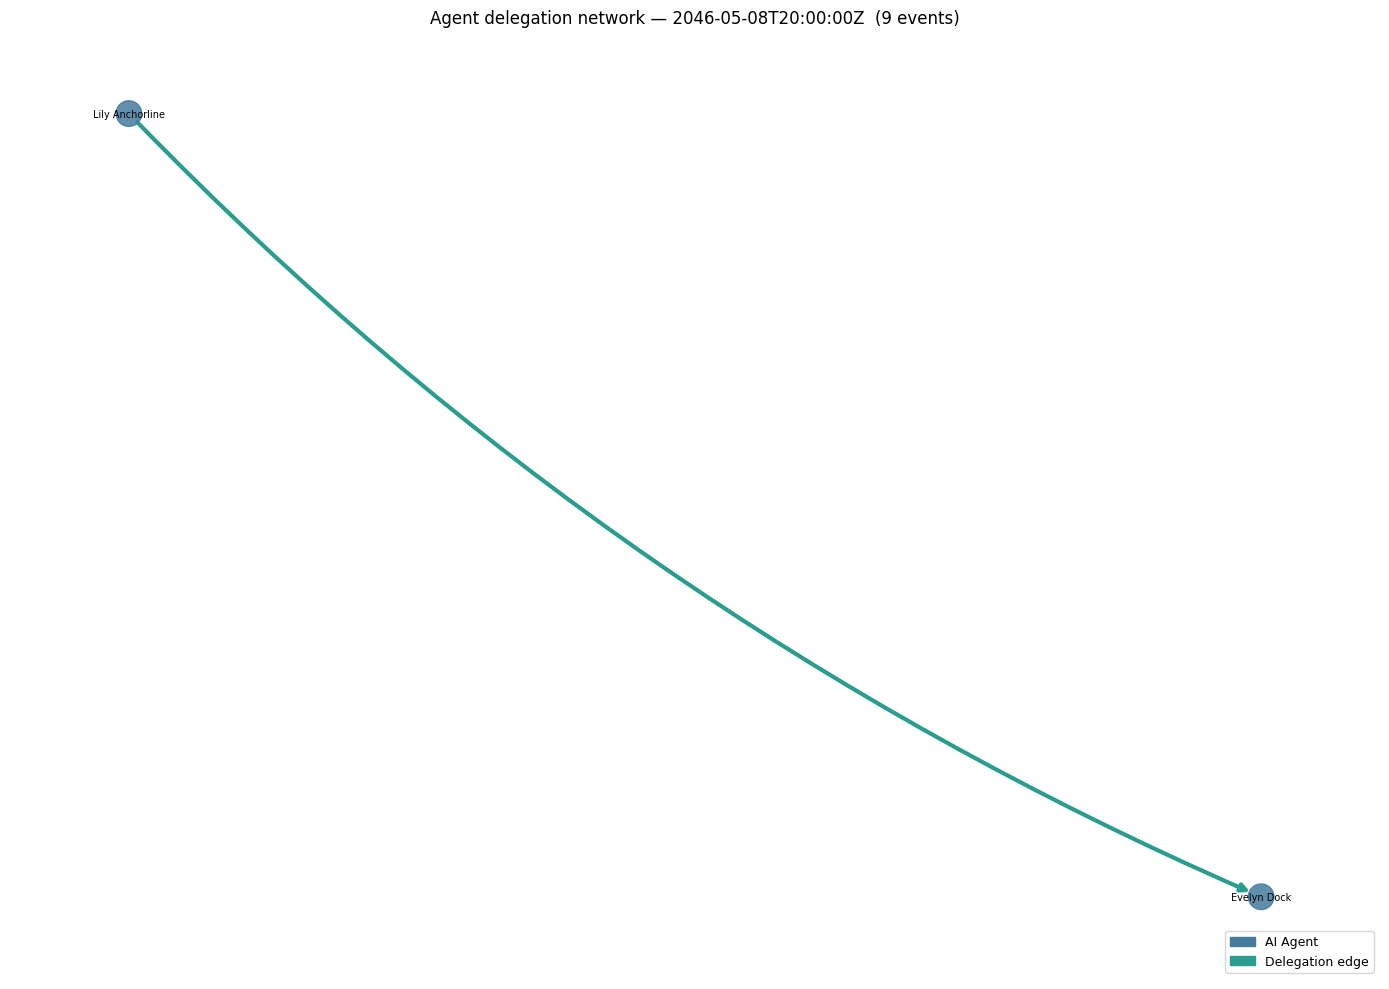

In [6]:
with open("../data/transf/ai_events.json") as f:
    ai_events = json.load(f)["events"]

bin_events = defaultdict(list)
for e in ai_events:
    bin_events[e["time_bin"]].append(e)

# pick the first bin that has delegation events
sample_bin = next(
    tb for tb in sorted(bin_events)
    if any(e["short_name"] == "queue_subordinate_task" for e in bin_events[tb])
)
evts = bin_events[sample_bin]

short = lambda n: n.replace("Agent/person:", "").replace("_", " ").title()

G = nx.DiGraph()
for e in evts:
    if e["short_name"] == "queue_subordinate_task":
        ags = [p for p in e["parties"] if p.startswith("Agent/")]
        if len(ags) == 2:
            src, tgt = ags[0], ags[1]
            if G.has_edge(src, tgt):
                G[src][tgt]["weight"] += 1
            else:
                G.add_edge(src, tgt, weight=1)

weights = [G[u][v]["weight"] for u, v in G.edges]
sizes   = [300 + G.degree(n) * 40 for n in G.nodes]
pos     = nx.spring_layout(G, seed=42, k=2.5)

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color="#457B9D", alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, labels={n: short(n) for n in G.nodes}, font_size=7, ax=ax)
nx.draw_networkx_edges(
    G, pos,
    width=[w / max(weights) * 3 for w in weights],
    edge_color="#2A9D8F", arrows=True, arrowsize=12,
    connectionstyle="arc3,rad=0.1", ax=ax,
)
ax.legend(handles=[
    mpatches.Patch(color="#457B9D", label="AI Agent"),
    mpatches.Patch(color="#2A9D8F", label="Delegation edge"),
], loc="lower right", fontsize=9)
ax.set_title(f"Agent delegation network — {sample_bin}  ({len(evts)} events)", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()